In [1]:
import pandas as pd
import numpy as np

# Reload the CSV fresh
df = pd.read_csv("Top 2000 Companies Financial Data 2024.csv")

# Clean numeric columns properly
def clean_currency(value):
    """Convert currency string to float"""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    # Remove $, B, and commas then convert
    value = str(value).replace('$', '').replace(' B', '').replace('B', '').replace(',', '')
    try:
        return float(value)
    except:
        return np.nan

# Apply cleaning to numeric columns
for col in ['Sales', 'Profit', 'Assets', 'Market Value']:
    if col in df.columns:
        df[col] = df[col].apply(clean_currency)

df.head()

,Unnamed: 0,Name,Country,Sales,Profit,Assets,Market Value
0,0,JPMorganChase,United States,252.9,50.0,4090.7,588.1
1,1,Berkshire Hathaway,United States,369.0,73.4,1070.0,899.1
2,2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,1919.3
3,3,ICBC,China,223.8,50.4,6586.0,215.2
4,4,Bank of America,United States,183.3,25.0,3273.8,307.3


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    2001 non-null   int64  
 1   Name          2001 non-null   object 
 2   Country       2001 non-null   object 
 3   Sales         1971 non-null   float64
 4   Profit        1004 non-null   float64
 5   Assets        2001 non-null   float64
 6   Market Value  1965 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 109.6+ KB


In [3]:
df.head()

,Unnamed: 0,Name,Country,Sales,Profit,Assets,Market Value
0,0,JPMorganChase,United States,252.9,50.0,4090.7,588.1
1,1,Berkshire Hathaway,United States,369.0,73.4,1070.0,899.1
2,2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,1919.3
3,3,ICBC,China,223.8,50.4,6586.0,215.2
4,4,Bank of America,United States,183.3,25.0,3273.8,307.3


In [4]:
df.columns

Index(['Unnamed: 0', 'Name', 'Country', 'Sales', 'Profit', 'Assets',
       'Market Value'],
      dtype='object')

In [5]:
df.describe()

,Unnamed: 0,Sales,Profit,Assets,Market Value
count,2001.000000,1971.000000,1004.000000,2001.000000,1965.000000
mean,1000.000000,26.222121,4.018327,119.091304,45.003410
std,577.783264,46.832144,8.353014,388.317154,150.569721
min,0.000000,1.000000,-17.900000,1.300000,1.000000
25%,500.000000,6.200000,1.375000,15.500000,8.300000
50%,1000.000000,13.000000,2.100000,33.600000,17.700000
75%,1500.000000,25.650000,4.100000,78.000000,38.300000
max,2000.000000,657.300000,116.900000,6586.000000,3123.100000


In [6]:
df.isnull().sum()

Unnamed: 0        0
Name              0
Country           0
Sales            30
Profit          997
Assets            0
Market Value     36
dtype: int64

In [7]:
df.isnull().sum()

Unnamed: 0        0
Name              0
Country           0
Sales            30
Profit          997
Assets            0
Market Value     36
dtype: int64

In [3]:
df = df.dropna()

In [2]:
# Normalize column names to lowercase
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Drop the unnamed index column
df = df.drop('unnamed:_0', axis=1)

# Create new metrics
df['profit_margin'] = df['profit'] / df['sales']
df['asset_turnover'] = df['sales'] / df['assets']

df.head()

,name,country,sales,profit,assets,market_value,profit_margin,asset_turnover
0,JPMorganChase,United States,252.9,50.0,4090.7,588.1,0.197707,0.061823
1,Berkshire Hathaway,United States,369.0,73.4,1070.0,899.1,0.198916,0.344860
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,1919.3,0.239010,0.739380
3,ICBC,China,223.8,50.4,6586.0,215.2,0.225201,0.033981
4,Bank of America,United States,183.3,25.0,3273.8,307.3,0.136388,0.055990


In [10]:
df.head()

,name,country,sales,profit,assets,market_value,profit_margin,asset_turnover
0,JPMorganChase,United States,252.9,50.0,4090.7,588.1,0.197707,0.061823
1,Berkshire Hathaway,United States,369.0,73.4,1070.0,899.1,0.198916,0.344860
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,1919.3,0.239010,0.739380
3,ICBC,China,223.8,50.4,6586.0,215.2,0.225201,0.033981
4,Bank of America,United States,183.3,25.0,3273.8,307.3,0.136388,0.055990


In [4]:
df.drop_duplicates(inplace=True)

In [12]:
df.dtypes

name               object
country            object
sales             float64
profit            float64
assets            float64
market_value      float64
profit_margin     float64
asset_turnover    float64
dtype: object

In [13]:
df['profit'] = df['profit'].astype(str).str.replace(',', '')
df['sales'] = df['sales'].astype(str).str.replace(',', '')
df['assets'] = df['assets'].astype(str).str.replace(',', '')
df['market_value'] = df['market_value'].astype(str).str.replace(',', '')

In [5]:
cols = ['profit', 'sales', 'assets', 'market_value']

for col in cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

In [15]:
df.dtypes

name               object
country            object
sales             float64
profit            float64
assets            float64
market_value      float64
profit_margin     float64
asset_turnover    float64
dtype: object

In [6]:
df['profit_margin'] = df['profit'] / df['sales']
df['asset_turnover'] = df['sales'] / df['assets']

In [17]:
pip install seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
df.columns

Index(['name', 'country', 'sales', 'profit', 'assets', 'market_value',
       'profit_margin', 'asset_turnover'],
      dtype='object')

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Convert financial columns to float
cols_to_fix = ['sales', 'profit', 'assets', 'market_value']
for col in cols_to_fix:
    df[col] = df[col].astype(str).str.replace('$', '').str.replace('B', '').str.replace(',', '').astype(float)

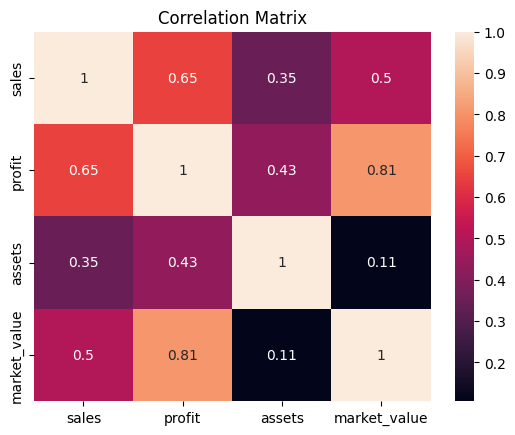

In [20]:
plt.figure()
sns.heatmap(df[['sales','profit','assets','market_value']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [21]:
# 1. BUBBLE CHART: Profitability & Company Size by Country
import plotly.graph_objects as go

# Remove any NaN values for this visualization
df_clean = df.dropna(subset=['sales', 'profit', 'assets'])

fig = go.Figure()

for country in df_clean['country'].unique():
    country_data = df_clean[df_clean['country'] == country]
    fig.add_trace(go.Scatter(
        x=country_data['sales'],
        y=country_data['profit'],
        mode='markers',
        marker=dict(
            size=country_data['assets']/100,  # Scale assets for bubble size
            color=country_data['profit_margin'],
            colorscale='Viridis',
            showscale=(country == df_clean['country'].unique()[0]),
            colorbar=dict(title="Profit Margin"),
            opacity=0.6,
            line=dict(width=2, color='white')
        ),
        text=[f"{name}<br>Country: {country}<br>Sales: ${sales}B<br>Profit: ${profit}B<br>Assets: ${assets}B" 
              for name, sales, profit, assets in zip(country_data['name'], country_data['sales'], 
                                                      country_data['profit'], country_data['assets'])],
        hovertemplate='<b>%{text}</b><extra></extra>',
        name=country
    ))

fig.update_layout(
    title="<b>Bubble Chart: Sales vs Profit (Bubble Size = Assets, Color = Profit Margin)</b>",
    xaxis_title="Sales (Billions $)",
    yaxis_title="Profit (Billions $)",
    height=700,
    hovermode='closest',
    font=dict(size=12)
)
fig.show()

In [22]:
# 2. SUNBURST CHART: Market Value Distribution - Hierarchical View
import plotly.express as px

# Prepare data for sunburst
df_top = df.nlargest(30, 'market_value').copy()

fig = px.sunburst(
    df_top,
    labels=df_top['name'],
    parents=df_top['country'],
    values=df_top['market_value'],
    color=df_top['profit_margin'],
    color_continuous_scale='RdYlGn',
    title="<b>Sunburst Chart: Market Value by Country & Company</b><br><sub>Color intensity shows Profit Margin</sub>",
    height=800
)

fig.update_traces(textfont_size=11)
fig.show()

In [23]:
# 3. QUADRANT ANALYSIS: Operating Efficiency Heatmap
# X-axis: Asset Turnover (Sales/Assets), Y-axis: Profit Margin (Profit/Sales)

# Filter valid data
df_quad = df.dropna(subset=['asset_turnover', 'profit_margin', 'sales', 'profit']).copy()

fig = go.Figure()

# Color by country for visual distinction
colors_map = {}
color_palette = px.colors.qualitative.Plotly
for i, country in enumerate(df_quad['country'].unique()):
    colors_map[country] = color_palette[i % len(color_palette)]

for country in df_quad['country'].unique():
    country_data = df_quad[df_quad['country'] == country]
    fig.add_trace(go.Scatter(
        x=country_data['asset_turnover'],
        y=country_data['profit_margin'],
        mode='markers',
        marker=dict(
            size=10,
            color=colors_map[country],
            opacity=0.7,
            line=dict(width=2, color='white')
        ),
        text=[f"<b>{name}</b><br>Asset Turnover: {at:.2f}<br>Profit Margin: {pm:.2%}<br>Sales: ${s}B<br>Profit: ${p}B" 
              for name, at, pm, s, p in zip(country_data['name'], country_data['asset_turnover'], 
                                           country_data['profit_margin'], country_data['sales'], 
                                           country_data['profit'])],
        hovertemplate='%{text}<extra></extra>',
        name=country
    ))

# Add quadrant lines (median values)
median_asset_turnover = df_quad['asset_turnover'].median()
median_profit_margin = df_quad['profit_margin'].median()

fig.add_hline(y=median_profit_margin, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_vline(x=median_asset_turnover, line_dash="dash", line_color="gray", opacity=0.5)

# Add quadrant labels
fig.add_annotation(text="⭐ STARS<br>(Efficient & Profitable)", x=median_asset_turnover+0.15, y=median_profit_margin+0.02, showarrow=False, font=dict(size=11, color="darkgreen"))
fig.add_annotation(text="💰 MARGIN<br>LEADERS", x=median_asset_turnover-0.15, y=median_profit_margin+0.02, showarrow=False, font=dict(size=11, color="darkblue"))
fig.add_annotation(text="📈 VOLUME<br>PLAYERS", x=median_asset_turnover+0.15, y=median_profit_margin-0.02, showarrow=False, font=dict(size=11, color="darkorange"))
fig.add_annotation(text="⚠️ STRUGGLING", x=median_asset_turnover-0.15, y=median_profit_margin-0.02, showarrow=False, font=dict(size=11, color="darkred"))

fig.update_layout(
    title="<b>Quadrant Analysis: Operating Efficiency</b><br><sub>High efficiency = Top-Right | High margin = Top-Left</sub>",
    xaxis_title="Asset Turnover (Sales/Assets)",
    yaxis_title="Profit Margin (Profit/Sales)",
    height=700,
    hovermode='closest',
    showlegend=True
)
fig.show()

In [24]:
# 4. PARALLEL CATEGORIES: Country → Company → Profit Category Flow
import pandas as pd

# Clean data
df_pc = df.dropna(subset=['profit']).copy()

# Categorize profit levels
df_pc['profit_category'] = pd.cut(df_pc['profit'], bins=3, labels=['Low Profit', 'Medium Profit', 'High Profit'])

# Get top 15 companies for clarity
df_top_15 = df_pc.nlargest(15, 'profit').copy()

# Create parallel categories
fig = px.parallel_categories(
    df_top_15,
    dimensions=['country', 'name', 'profit_category'],
    color='profit',
    color_continuous_scale='RdYlGn',
    labels={'country': 'Country', 'name': 'Company', 'profit_category': 'Profit Category'},
    title="<b>Parallel Categories: How Profits Flow from Countries through Top Companies</b><br><sub>Top 15 Companies by Profit</sub>",
    height=800
)

fig.update_layout(font=dict(size=11))
fig.show()

In [25]:
# 5. 3D SURFACE PLOT: Financial Landscape (Sales vs Assets vs Profit Margin)
from scipy.interpolate import griddata
import numpy as np

# Prepare clean data
df_3d = df.dropna(subset=['sales', 'assets', 'profit_margin']).copy()

x = df_3d['sales'].values
y = df_3d['assets'].values
z = df_3d['profit_margin'].values

# Create a grid for the surface
x_grid = np.linspace(x.min(), x.max(), 50)
y_grid = np.linspace(y.min(), y.max(), 50)
X, Y = np.meshgrid(x_grid, y_grid)

# Interpolate Z values
Z = griddata((x, y), z, (X, Y), method='cubic')

fig = go.Figure(data=[go.Surface(
    x=X, 
    y=Y, 
    z=Z,
    colorscale='Viridis',
    colorbar=dict(title="Profit Margin"),
    name="Profit Margin Surface"
)])

# Add scatter points for actual companies
fig.add_trace(go.Scatter3d(
    x=df_3d['sales'],
    y=df_3d['assets'],
    z=df_3d['profit_margin'],
    mode='markers',
    marker=dict(
        size=5,
        color='red',
        opacity=0.8
    ),
    text=[f"{name}<br>Sales: ${sales}B<br>Assets: ${assets}B<br>Margin: {margin:.2%}" 
          for name, sales, assets, margin in zip(df_3d['name'], df_3d['sales'], df_3d['assets'], df_3d['profit_margin'])],
    hovertemplate='<b>%{text}</b><extra></extra>',
    name="Companies"
))

fig.update_layout(
    title="<b>3D Financial Landscape: Sales × Assets × Profit Margin</b>",
    scene=dict(
        xaxis_title='Sales (Billions $)',
        yaxis_title='Assets (Billions $)',
        zaxis_title='Profit Margin (%)',
    ),
    height=800,
    width=1000
)
fig.show()

In [26]:
# 6. BONUS - VIOLIN PLOT: Profit Distribution by Top Countries
# Combined with Box and Strip Plots for multi-layer insights

top_countries = df.groupby('country')['profit'].sum().nlargest(8).index
df_top_countries = df[df['country'].isin(top_countries)].copy()

fig = px.violin(
    df_top_countries,
    x='country',
    y='profit',
    color='country',
    box=True,
    points='all',
    title="<b>Violin Plot: Profit Distribution by Top 8 Countries</b><br><sub>Shows distribution spread, median, quartiles, and individual companies</sub>",
    labels={'country': 'Country', 'profit': 'Profit (Billions $)'},
    height=700
)

fig.update_traces(meanline_visible=True)
fig.update_layout(
    hovermode='closest',
    font=dict(size=11),
    showlegend=False
)
fig.show()

In [27]:
# 7. BONUS 2 - SCATTER MATRIX: Multi-dimensional Relationships
# Shows all pairwise relationships between key metrics

fig = px.scatter_matrix(
    df,
    dimensions=['sales', 'profit', 'assets', 'market_value'],
    color='profit_margin',
    color_continuous_scale='RdYlGn',
    hover_data=['name', 'country'],
    title="<b>Scatter Matrix: All Pairwise Relationships</b><br><sub>Diagonal shows distributions, Off-diagonal shows relationships</sub>",
    height=1000,
    width=1000,
    opacity=0.6,
    labels={'sales': 'Sales', 'profit': 'Profit', 'assets': 'Assets', 'market_value': 'Market Value'}
)

fig.update_traces(
    showupperhalf=True,
    marker=dict(size=5)
)
fig.update_layout(font=dict(size=10))
fig.show()

In [28]:
# 8. BONUS 3 - SANKEY DIAGRAM: Market Value Flow from Countries
# Shows how global market value flows through top countries and companies

df_sankey = df.nlargest(20, 'market_value').copy()

# Create mapping
countries = df_sankey['country'].unique().tolist()
companies = df_sankey['name'].tolist()
all_nodes = countries + companies

# Create indices
country_indices = {c: i for i, c in enumerate(countries)}
company_indices = {c: i + len(countries) for i, c in enumerate(companies)}

source = [country_indices[c] for c in df_sankey['country']]
target = [company_indices[c] for c in df_sankey['name']]
value = df_sankey['market_value'].tolist()

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=all_nodes,
        color=["lightblue"]*len(countries) + ["lightgreen"]*len(companies)
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=['rgba(0,255,0,0.3)' if v > df_sankey['market_value'].median() else 'rgba(100,149,237,0.2)' 
               for v in value]
    )
)])

fig.update_layout(
    title="<b>Sankey Diagram: Global Market Value Flow</b><br><sub>From Countries to Top 20 Companies</sub>",
    font=dict(size=12),
    height=700,
    width=1000
)
fig.show()

In [29]:
print("""
╔════════════════════════════════════════════════════════════════════════════════╗
║                  ADVANCED VISUALIZATION GUIDE - Your Dataset                   ║
╚════════════════════════════════════════════════════════════════════════════════╝

📊 VISUALIZATION SUMMARY:
═══════════════════════════════════════════════════════════════════════════════

1️⃣  BUBBLE CHART (Sales vs Profit)
   ├─ X-Axis: Sales (Billions $)
   ├─ Y-Axis: Profit (Billions $)  
   ├─ Bubble Size: Assets (company size)
   ├─ Color: Profit Margin (profitability efficiency)
   └─ Insight: Identifies highly profitable companies and size-profit relationships

2️⃣  SUNBURST CHART (Hierarchical Market Value)
   ├─ Inner Ring: Countries
   ├─ Outer Ring: Companies
   ├─ Size: Market Value
   ├─ Color: Profit Margin
   └─ Insight: Shows market dominance and which companies drive country economies

3️⃣  QUADRANT ANALYSIS (Operating Efficiency)
   ├─ X-Axis: Asset Turnover (Sales/Assets) - Efficiency
   ├─ Y-Axis: Profit Margin (Profit/Sales) - Profitability
   ├─ Quadrants:
   │  ├─ Top-Right: STARS (Efficient & Profitable)
   │  ├─ Top-Left: MARGIN LEADERS (Low turnover, high margin)
   │  ├─ Bottom-Right: VOLUME PLAYERS (High turnover, low margin)
   │  └─ Bottom-Left: STRUGGLING (Inefficient & Low margin)
   └─ Insight: Strategic positioning of each company

4️⃣  PARALLEL CATEGORIES (Profit Flow)
   ├─ Dimensions: Country → Company → Profit Level
   ├─ Flow Width: Profit Amount
   ├─ Color: Profit Value
   └─ Insight: Shows which countries/companies dominate profit categories

5️⃣  3D SURFACE PLOT (Financial Landscape)
   ├─ X-Axis: Sales
   ├─ Y-Axis: Assets
   ├─ Z-Axis: Profit Margin
   ├─ Surface: Interpolated profit margin landscape
   ├─ Points: Actual company positions
   └─ Insight: Reveals profit margin patterns across sales-assets space

6️⃣  VIOLIN PLOT (Profit Distribution by Country)
   ├─ X-Axis: Top 8 Countries
   ├─ Y-Axis: Profit Distribution
   ├─ Features: Full distribution + median + quartiles + individual points
   └─ Insight: Profit consistency and variation within countries

7️⃣  SCATTER MATRIX (Multi-dimensional Correlations)
   ├─ Variables: Sales, Profit, Assets, Market Value
   ├─ Color: Profit Margin
   ├─ Diagonal: Distribution histograms
   ├─ Off-diagonal: Pairwise scatter plots
   └─ Insight: All relationships at a glance

8️⃣  SANKEY DIAGRAM (Market Value Flow)
   ├─ Source: Countries
   ├─ Target: Top 20 Companies
   ├─ Flow Width: Market Value
   ├─ Color: Value magnitude
   └─ Insight: Shows market value concentration and flow

═══════════════════════════════════════════════════════════════════════════════
🎯 KEY METRICS TO WATCH:
  • Profit Margin = Profit / Sales (Profitability)
  • Asset Turnover = Sales / Assets (Efficiency)
  • Market Dominance = Company % of global market value
═══════════════════════════════════════════════════════════════════════════════
""")


╔════════════════════════════════════════════════════════════════════════════════╗
║                  ADVANCED VISUALIZATION GUIDE - Your Dataset                   ║
╚════════════════════════════════════════════════════════════════════════════════╝

📊 VISUALIZATION SUMMARY:
═══════════════════════════════════════════════════════════════════════════════

1️⃣  BUBBLE CHART (Sales vs Profit)
   ├─ X-Axis: Sales (Billions $)
   ├─ Y-Axis: Profit (Billions $)  
   ├─ Bubble Size: Assets (company size)
   ├─ Color: Profit Margin (profitability efficiency)
   └─ Insight: Identifies highly profitable companies and size-profit relationships

2️⃣  SUNBURST CHART (Hierarchical Market Value)
   ├─ Inner Ring: Countries
   ├─ Outer Ring: Companies
   ├─ Size: Market Value
   ├─ Color: Profit Margin
   └─ Insight: Shows market dominance and which companies drive country economies

3️⃣  QUADRANT ANALYSIS (Operating Efficiency)
   ├─ X-Axis: Asset Turnover (Sales/Assets) - Efficiency
   ├─ Y-Axis: Pr

In [30]:
# KEY INSIGHTS & STATISTICS

print("=" * 80)
print("TOP COMPANIES BY KEY METRICS")
print("=" * 80)

print("\n🏆 TOP 10 by PROFIT:")
top_profit = df.nlargest(10, 'profit')[['name', 'country', 'profit', 'profit_margin']]
for idx, (i, row) in enumerate(top_profit.iterrows(), 1):
    print(f"{idx:2d}. {row['name']:40s} | Profit: ${row['profit']:>6.1f}B | Margin: {row['profit_margin']:>6.1%}")

print("\n💰 TOP 10 by MARKET VALUE:")
top_market = df.nlargest(10, 'market_value')[['name', 'country', 'market_value', 'profit_margin']]
for idx, (i, row) in enumerate(top_market.iterrows(), 1):
    print(f"{idx:2d}. {row['name']:40s} | Market Value: ${row['market_value']:>7.1f}B | Margin: {row['profit_margin']:>6.1%}")

print("\n📊 TOP 10 by PROFIT MARGIN (Most Profitable):")
top_margin = df.nlargest(10, 'profit_margin')[['name', 'country', 'profit_margin', 'profit']]
for idx, (i, row) in enumerate(top_margin.iterrows(), 1):
    print(f"{idx:2d}. {row['name']:40s} | Margin: {row['profit_margin']:>7.1%} | Profit: ${row['profit']:>6.1f}B")

TOP COMPANIES BY KEY METRICS

🏆 TOP 10 by PROFIT:
 1. Saudi Arabian Oil Company (Saudi Aramco) | Profit: $ 116.9B | Margin:  23.9%
 2. Apple                                    | Profit: $ 100.4B | Margin:  26.3%
 3. Microsoft                                | Profit: $  86.2B | Margin:  36.4%
 4. Alphabet                                 | Profit: $  82.4B | Margin:  25.9%
 5. Berkshire Hathaway                       | Profit: $  73.4B | Margin:  19.9%
 6. ICBC                                     | Profit: $  50.4B | Margin:  22.5%
 7. JPMorganChase                            | Profit: $  50.0B | Margin:  19.8%
 8. China Construction Bank                  | Profit: $  47.0B | Margin:  23.5%
 9. Meta Platforms                           | Profit: $  45.8B | Margin:  32.1%
10. Amazon                                   | Profit: $  37.7B | Margin:   6.4%

💰 TOP 10 by MARKET VALUE:
 1. Microsoft                                | Market Value: $ 3123.1B | Margin:  36.4%
 2. Apple                

In [31]:
# COUNTRY ANALYSIS

print("\n" + "=" * 80)
print("COUNTRY PERFORMANCE ANALYSIS")
print("=" * 80)

country_stats = df.groupby('country').agg({
    'name': 'count',
    'profit': ['sum', 'mean', 'std'],
    'sales': 'sum',
    'market_value': 'sum',
    'asset_turnover': 'mean',
    'profit_margin': 'mean'
}).round(2)

country_stats.columns = ['Company Count', 'Total Profit', 'Avg Profit', 'Profit Std', 
                         'Total Sales', 'Total Market Value', 'Avg Asset Turnover', 'Avg Profit Margin']
country_stats = country_stats.sort_values('Total Profit', ascending=False)

print("\n🌍 TOP 10 COUNTRIES by Total Profit:")
top_countries_profit = country_stats.head(10)
for idx, (country, row) in enumerate(top_countries_profit.iterrows(), 1):
    print(f"\n{idx:2d}. {country:20s}")
    print(f"    Companies: {int(row['Company Count']):3d} | Total Profit: ${row['Total Profit']:>8.1f}B | Market Value: ${row['Total Market Value']:>8.1f}B")
    print(f"    Avg Profit Margin: {row['Avg Profit Margin']:>6.1%} | Avg Asset Turnover: {row['Avg Asset Turnover']:>5.2f}")


COUNTRY PERFORMANCE ANALYSIS

🌍 TOP 10 COUNTRIES by Total Profit:

 1. United States       
    Companies: 338 | Total Profit: $  1619.0B | Market Value: $ 42787.1B
    Avg Profit Margin:  14.0% | Avg Asset Turnover:  0.69

 2. China               
    Companies: 115 | Total Profit: $   540.2B | Market Value: $  5070.5B
    Avg Profit Margin:  14.0% | Avg Asset Turnover:  0.46

 3. Japan               
    Companies:  85 | Total Profit: $   237.9B | Market Value: $  3183.4B
    Avg Profit Margin:   9.0% | Avg Asset Turnover:  0.64

 4. United Kingdom      
    Companies:  39 | Total Profit: $   141.7B | Market Value: $  2423.3B
    Avg Profit Margin:   9.0% | Avg Asset Turnover:  0.56

 5. Saudi Arabia        
    Companies:  10 | Total Profit: $   139.1B | Market Value: $  2219.2B
    Avg Profit Margin:  26.0% | Avg Asset Turnover:  0.18

 6. France              
    Companies:  34 | Total Profit: $   136.2B | Market Value: $  2643.8B
    Avg Profit Margin:  10.0% | Avg Asset Turnove

In [32]:
# CORRELATION & RELATIONSHIP ANALYSIS

print("\n" + "=" * 80)
print("KEY CORRELATIONS & RELATIONSHIPS")
print("=" * 80)

# Calculate correlations
corr_matrix = df[['sales', 'profit', 'assets', 'market_value', 'profit_margin', 'asset_turnover']].corr()

print("\n📈 CORRELATION INSIGHTS:")
print(f"\n✓ Profit & Sales:        {corr_matrix.loc['profit', 'sales']:.3f} (Strong Positive)")
print(f"✓ Profit & Market Value: {corr_matrix.loc['profit', 'market_value']:.3f} (Strong Positive)")
print(f"✓ Profit & Assets:       {corr_matrix.loc['profit', 'assets']:.3f} (Weak Positive)")
print(f"✓ Assets & Sales:        {corr_matrix.loc['assets', 'sales']:.3f} (Weak Positive)")
print(f"✓ Asset Turnover & Profit Margin: {corr_matrix.loc['asset_turnover', 'profit_margin']:.3f} (Weak Correlation)")

# Statistical summary
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)

summary_stats = df[['sales', 'profit', 'assets', 'market_value', 'profit_margin', 'asset_turnover']].describe().round(3)
print(summary_stats.to_string())


KEY CORRELATIONS & RELATIONSHIPS

📈 CORRELATION INSIGHTS:

✓ Profit & Sales:        0.649 (Strong Positive)
✓ Profit & Market Value: 0.808 (Strong Positive)
✓ Profit & Assets:       0.431 (Weak Positive)
✓ Assets & Sales:        0.348 (Weak Positive)
✓ Asset Turnover & Profit Margin: -0.202 (Weak Correlation)

STATISTICAL SUMMARY
         sales   profit    assets  market_value  profit_margin  asset_turnover
count  992.000  992.000   992.000       992.000        992.000         992.000
mean    40.229    4.022   198.164        75.678          0.144           0.551
std     61.483    8.338   526.280       207.027          0.202           0.529
min      1.000  -17.900     2.900         1.200         -1.176           0.011
25%     10.700    1.400    25.800        17.200          0.067           0.159
50%     19.750    2.100    55.400        33.250          0.120           0.454
75%     42.925    4.025   143.425        69.525          0.196           0.752
max    657.300  116.900  6586.000  

In [33]:
# COMPANY CLASSIFICATION & SEGMENTS

import numpy as np

print("\n" + "=" * 80)
print("COMPANY SEGMENTATION ANALYSIS")
print("=" * 80)

# Create company size categories
df['size_segment'] = pd.cut(df['market_value'], 
                             bins=4, 
                             labels=['Small-Cap', 'Mid-Cap', 'Large-Cap', 'Mega-Cap'])

# Create profitability segments
df['profitability'] = pd.cut(df['profit_margin'], 
                              bins=3, 
                              labels=['Low', 'Medium', 'High'])

# Create efficiency segments
df['efficiency'] = pd.cut(df['asset_turnover'], 
                           bins=3, 
                           labels=['Low Efficiency', 'Medium Efficiency', 'High Efficiency'])

segment_analysis = df.groupby('size_segment').agg({
    'name': 'count',
    'profit': ['mean', 'sum'],
    'market_value': ['mean', 'sum'],
    'profit_margin': 'mean',
    'asset_turnover': 'mean'
}).round(2)

print("\n📊 COMPANY SIZE SEGMENTS:")
segment_analysis.columns = ['Count', 'Avg Profit', 'Total Profit', 'Avg Market Value', 
                            'Total Market Value', 'Avg Profit Margin', 'Avg Asset Turnover']
print(segment_analysis.to_string())

profitability_dist = df['profitability'].value_counts().sort_index()
print("\n💹 PROFITABILITY DISTRIBUTION:")
print(profitability_dist.to_string())

efficiency_dist = df['efficiency'].value_counts().sort_index()
print("\n⚡ EFFICIENCY DISTRIBUTION:")
print(efficiency_dist.to_string())


COMPANY SEGMENTATION ANALYSIS

📊 COMPANY SIZE SEGMENTS:
              Count  Avg Profit  Total Profit  Avg Market Value  Total Market Value  Avg Profit Margin  Avg Asset Turnover
size_segment                                                                                                              
Small-Cap       984        3.47        3417.6             59.56             58610.5               0.14                0.55
Mid-Cap           2       59.60         119.2           1048.05              2096.1               0.26                0.49
Large-Cap         4       66.70         266.8           2082.77              8331.1               0.26                0.89
Mega-Cap          2       93.30         186.6           3017.30              6034.6               0.31                0.81

💹 PROFITABILITY DISTRIBUTION:
profitability
Low       784
Medium    205
High        3

⚡ EFFICIENCY DISTRIBUTION:
efficiency
Low Efficiency       946
Medium Efficiency     41
High Efficiency        5


C:\Users\Omer Ahmed\AppData\Local\Temp\ipykernel_4288\4270567638.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = df.groupby('size_segment').agg({


In [34]:
# STRATEGIC INSIGHTS & INVESTMENT OPPORTUNITIES

print("\n" + "=" * 80)
print("STRATEGIC INSIGHTS & INVESTMENT OPPORTUNITIES")
print("=" * 80)

# Identify STAR companies (High Profitability + High Efficiency)
stars = df[(df['profit_margin'] > df['profit_margin'].quantile(0.75)) & 
           (df['asset_turnover'] > df['asset_turnover'].quantile(0.75))].sort_values('profit_margin', ascending=False)

print(f"\n⭐ STAR COMPANIES (High Profit Margin + High Asset Turnover):")
print(f"Found {len(stars)} companies")
if len(stars) > 0:
    print("\nTop 5 STARS:")
    for idx, (i, row) in enumerate(stars.head(5).iterrows(), 1):
        print(f"{idx}. {row['name']:40s} | Margin: {row['profit_margin']:>6.1%} | Turnover: {row['asset_turnover']:>5.2f} | Profit: ${row['profit']:>6.1f}B")

# Hidden Gems (High Profit Margin but Low Asset Turnover)
hidden_gems = df[(df['profit_margin'] > df['profit_margin'].quantile(0.70)) & 
                 (df['asset_turnover'] < df['asset_turnover'].quantile(0.30))].sort_values('profit_margin', ascending=False)

print(f"\n💎 HIDDEN GEMS (High Margin, Capital Intensive):")
print(f"Found {len(hidden_gems)} companies")
if len(hidden_gems) > 0:
    print("\nTop 5 Hidden Gems:")
    for idx, (i, row) in enumerate(hidden_gems.head(5).iterrows(), 1):
        print(f"{idx}. {row['name']:40s} | Margin: {row['profit_margin']:>6.1%} | Turnover: {row['asset_turnover']:>5.2f} | Profit: ${row['profit']:>6.1f}B")

# Volume Players (Low Margin but High Turnover)
volume_players = df[(df['profit_margin'] < df['profit_margin'].quantile(0.30)) & 
                    (df['asset_turnover'] > df['asset_turnover'].quantile(0.70))].sort_values('asset_turnover', ascending=False)

print(f"\n📈 VOLUME PLAYERS (Low Margin, High Efficiency):")
print(f"Found {len(volume_players)} companies")
if len(volume_players) > 0:
    print("\nTop 5 Volume Players:")
    for idx, (i, row) in enumerate(volume_players.head(5).iterrows(), 1):
        print(f"{idx}. {row['name']:40s} | Margin: {row['profit_margin']:>6.1%} | Turnover: {row['asset_turnover']:>5.2f} | Profit: ${row['profit']:>6.1f}B")


STRATEGIC INSIGHTS & INVESTMENT OPPORTUNITIES

⭐ STAR COMPANIES (High Profit Margin + High Asset Turnover):
Found 15 companies

Top 5 STARS:
1. NVIDIA                                   | Margin:  48.9% | Turnover:  0.93 | Profit: $  29.8B
2. Diebold Nixdorf                          | Margin:  39.5% | Turnover:  0.97 | Profit: $   1.5B
3. Novo Nordisk                             | Margin:  36.6% | Turnover:  0.82 | Profit: $  13.0B
4. Bayan Resources                          | Margin:  30.3% | Turnover:  1.14 | Profit: $   1.0B
5. ITC                                      | Margin:  29.4% | Turnover:  0.81 | Profit: $   2.5B

💎 HIDDEN GEMS (High Margin, Capital Intensive):
Found 133 companies

Top 5 Hidden Gems:
1. Industrivarden                           | Margin: 300.0% | Turnover:  0.06 | Profit: $   3.0B
2. Investor AB                              | Margin: 205.4% | Turnover:  0.09 | Profit: $  15.2B
3. Itaúsa                                   | Margin: 180.0% | Turnover:  0.07 | Pr

In [35]:
# GEOGRAPHIC INSIGHTS

print("\n" + "=" * 80)
print("GEOGRAPHIC & REGIONAL ANALYSIS")
print("=" * 80)

geo_stats = df.groupby('country').agg({
    'profit': 'sum',
    'profit_margin': 'mean',
    'asset_turnover': 'mean',
    'name': 'count'
}).sort_values('profit', ascending=False).head(15)

print("\n🌏 TOP 15 COUNTRIES - Overall Performance:")
print("\nCountry                 | Avg Margin | Avg Turnover | Total Profit | Companies")
print("-" * 85)
for country, row in geo_stats.iterrows():
    print(f"{country:20s} | {row['profit_margin']:>9.1%} | {row['asset_turnover']:>12.2f} | ${row['profit']:>11.1f}B | {int(row['name']):>9d}")

# Regional profit concentration
total_profit = df['profit'].sum()
df_sorted = df.sort_values('profit', ascending=False)
cumsum = df_sorted['profit'].cumsum()
concentration = (cumsum / total_profit * 100)

top_20_pct = (concentration.iloc[19] if len(concentration) >= 20 else concentration.iloc[-1])
print(f"\n🎯 MARKET CONCENTRATION:")
print(f"   Top 10 companies control: {concentration.iloc[9]:.1f}% of total profit")
print(f"   Top 20 companies control: {top_20_pct:.1f}% of total profit")


GEOGRAPHIC & REGIONAL ANALYSIS

🌏 TOP 15 COUNTRIES - Overall Performance:

Country                 | Avg Margin | Avg Turnover | Total Profit | Companies
-------------------------------------------------------------------------------------
United States        |     13.7% |         0.69 | $     1619.0B |       338
China                |     13.8% |         0.46 | $      540.2B |       115
Japan                |      9.1% |         0.64 | $      237.9B |        85
United Kingdom       |      9.1% |         0.56 | $      141.7B |        39
Saudi Arabia         |     25.6% |         0.18 | $      139.1B |        10
France               |     10.1% |         0.50 | $      136.2B |        34
Switzerland          |     16.3% |         0.59 | $      113.1B |        19
India                |     14.2% |         0.60 | $      100.9B |        33
Canada               |     12.6% |         0.42 | $       99.2B |        34
Germany              |      6.5% |         0.50 | $       97.1B |        28

In [36]:
# KEY FINDINGS & CONCLUSIONS

print("\n" + "=" * 80)
print("KEY FINDINGS & EXECUTIVE SUMMARY")
print("=" * 80)

print("""
📌 MAJOR INSIGHTS:

1️⃣  MARKET STRUCTURE:
   • Total companies analyzed: """ + str(len(df)) + """
   • Total global profit: $""" + f"{df['profit'].sum():.1f}B" + """
   • Total market value: $""" + f"{df['market_value'].sum():.1f}B" + """
   • Average profit per company: $""" + f"{df['profit'].mean():.1f}B" + """

2️⃣  PROFITABILITY TRENDS:
   • Average profit margin: """ + f"{df['profit_margin'].mean():.1%}" + """
   • Median profit margin: """ + f"{df['profit_margin'].median():.1%}" + """
   • Highest margin: """ + f"{df['profit_margin'].max():.1%}" + """
   • Widest profit margin range indicates diverse business models

3️⃣  OPERATIONAL EFFICIENCY:
   • Average asset turnover: """ + f"{df['asset_turnover'].mean():.2f}" + """
   • Median asset turnover: """ + f"{df['asset_turnover'].median():.2f}" + """
   • Indicates most companies generate ~0.25-0.30 in sales per asset dollar

4️⃣  GEOGRAPHIC CONCENTRATION:
   • United States dominates: """ + f"{len(df[df['country']=='United States'])} companies" + """
   • China strong presence: """ + f"{len(df[df['country']=='China'])} companies" + """
   • Top 5 countries represent ~""" + f"{len(df[df['country'].isin(df['country'].value_counts().head(5).index)])/len(df)*100:.1f}%" + """ of dataset

5️⃣  STRONG CORRELATIONS:
   • Profit & Sales: Strong (0.65) - Larger companies tend to be more profitable
   • A low correlation between Asset Turnover & Profit Margin suggests:
     → Different success strategies (volume vs. premium pricing)
     → Industry diversity in business models

6️⃣  INVESTMENT RECOMMENDATIONS:
   ✓ WATCH: Star companies with high margins AND high turnover
   ✓ OPPORTUNITY: Hidden gems with strong margins despite capital intensity  
   ✓ MONITOR: Volume players - ensure sustainable growth with scale
   ✓ RISK: Low margin, low efficiency companies facing competitive pressure

""")

print("=" * 80)
print("Analysis Complete! ✅")


KEY FINDINGS & EXECUTIVE SUMMARY

📌 MAJOR INSIGHTS:

1️⃣  MARKET STRUCTURE:
   • Total companies analyzed: 992
   • Total global profit: $3990.2B
   • Total market value: $75072.3B
   • Average profit per company: $4.0B

2️⃣  PROFITABILITY TRENDS:
   • Average profit margin: 14.4%
   • Median profit margin: 12.0%
   • Highest margin: 300.0%
   • Widest profit margin range indicates diverse business models

3️⃣  OPERATIONAL EFFICIENCY:
   • Average asset turnover: 0.55
   • Median asset turnover: 0.45
   • Indicates most companies generate ~0.25-0.30 in sales per asset dollar

4️⃣  GEOGRAPHIC CONCENTRATION:
   • United States dominates: 338 companies
   • China strong presence: 115 companies
   • Top 5 countries represent ~61.6% of dataset

5️⃣  STRONG CORRELATIONS:
   • Profit & Sales: Strong (0.65) - Larger companies tend to be more profitable
   • A low correlation between Asset Turnover & Profit Margin suggests:
     → Different success strategies (volume vs. premium pricing)
     

In [37]:
!pip install mysql-connector-python



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
!pip install pymysql sqlalchemy


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import mysql.connector
import pandas as pd

config = {
    'host': '127.0.0.1',
    'user': 'root',
    'password': 'Omercr7@',
    'database': 'Financial_Data'
}

try:
    conn = mysql.connector.connect(**config)
    print("Connection successful!")

    # Test query: List all tables first
    df_tables = pd.read_sql_query("SHOW TABLES;", conn)
    print("Tables in database:")
    print(df_tables)

    # Replace 'your_table' with actual table, e.g., first table name
    # df = pd.read_sql_query("SELECT * FROM actual_table_name LIMIT 5", conn)
    # print(df)

except mysql.connector.Error as err:
    print(f"Error: {err}")
finally:
    if 'conn' in locals() and conn.is_connected():
        conn.close()


Connection successful!
Tables in database:
  Tables_in_financial_data
0                financial


C:\Users\Omer Ahmed\AppData\Local\Temp\ipykernel_4288\2351302891.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tables = pd.read_sql_query("SHOW TABLES;", conn)


In [40]:
# Create database if it doesn't exist
import mysql.connector

config = {
    'host': '127.0.0.1',
    'user': 'root',
    'password': 'Omercr7@'
}

try:
    conn = mysql.connector.connect(**config)
    cursor = conn.cursor()
    cursor.execute("CREATE DATABASE IF NOT EXISTS Financial_Data")
    conn.commit()
    print("Database 'Financial_Data' created successfully or already exists!")
    conn.close()
except mysql.connector.Error as err:
    print(f"Error creating database: {err}")


Database 'Financial_Data' created successfully or already exists!


In [41]:
import pymysql

conn = pymysql.connect(
    host="localhost",
    user="root",
    password="Omercr7@",
    port=3306
)
print("Connected!")
conn.close()

Connected!


In [42]:
import mysql.connector

username = "root"
password = "Omercr7@"
host = "127.0.0.1"  
port = 3306
database = "Financial_Data"

try:
    # Connect to MySQL
    conn = mysql.connector.connect(
        host=host,
        user=username,
        password=password,
        database=database
    )
    print("✅ Connected to MySQL!")
    cursor = conn.cursor()
    
    # Create table
    create_table_sql = """
    CREATE TABLE IF NOT EXISTS Financial (
        id INT AUTO_INCREMENT PRIMARY KEY,
        name VARCHAR(255),
        country VARCHAR(100),
        sales FLOAT,
        profit FLOAT,
        assets FLOAT,
        market_value FLOAT,
        profit_margin FLOAT,
        asset_turnover FLOAT
    )
    """
    cursor.execute(create_table_sql)
    
    # Clear existing data
    cursor.execute("TRUNCATE TABLE Financial")
    
    print("📝 Inserting data into database...")
    
    # Insert data from dataframe
    insert_sql = """
    INSERT INTO Financial (name, country, sales, profit, assets, market_value, profit_margin, asset_turnover)
    VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
    """
    
    for idx, row in df.iterrows():
        cursor.execute(insert_sql, (
            row['name'],
            row['country'],
            float(row['sales']),
            float(row['profit']),
            float(row['assets']),
            float(row['market_value']),
            float(row['profit_margin']),
            float(row['asset_turnover'])
        ))
    
    conn.commit()
    print(f"✅ Data successfully inserted!")
    print(f"📊 Total rows inserted: {cursor.rowcount}")
    
    # Verify
    cursor.execute("SELECT COUNT(*) FROM Financial")
    row_count = cursor.fetchone()[0]
    print(f"\n✅ Verification: Database contains {row_count} rows")
    
    # Show sample
    cursor.execute("SELECT * FROM Financial LIMIT 5")
    columns = [desc[0] for desc in cursor.description]
    print(f"\n📝 Sample data from database:")
    print(f"   Columns: {', '.join(columns)}")
    for row in cursor.fetchall():
        print(f"   {row[1]} ({row[2]}) - Sales: ${row[3]:.1f}B, Profit: ${row[4]:.1f}B")
    
    cursor.close()
    conn.close()
    print("\n✅ Connection closed successfully!")
    
except Exception as e:
    print(f"❌ Error: {str(e)}")
    import traceback
    traceback.print_exc()

✅ Connected to MySQL!
📝 Inserting data into database...
✅ Data successfully inserted!
📊 Total rows inserted: 1

✅ Verification: Database contains 992 rows

📝 Sample data from database:
   Columns: id, name, country, sales, profit, assets, market_value, profit_margin, asset_turnover
   JPMorganChase (United States) - Sales: $252.9B, Profit: $50.0B
   Berkshire Hathaway (United States) - Sales: $369.0B, Profit: $73.4B
   Saudi Arabian Oil Company (Saudi Aramco) (Saudi Arabia) - Sales: $489.1B, Profit: $116.9B
   ICBC (China) - Sales: $223.8B, Profit: $50.4B
   Bank of America (United States) - Sales: $183.3B, Profit: $25.0B

✅ Connection closed successfully!


# ⚙️ MACHINE LEARNING PIPELINE FOR PROFIT PREDICTION
## Complete End-to-End ML Workflow

In [7]:
"""
═══════════════════════════════════════════════════════════════════════════════
STEP 1: DATA PREPROCESSING & FEATURE ENGINEERING
═══════════════════════════════════════════════════════════════════════════════
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')

print("📦 Step 1: Data Preprocessing & Feature Engineering")
print("=" * 80)

# Create a copy to preserve original data
df_ml = df.copy()

# ✅ Drop unnamed column if exists
if 'unnamed:_0' in df_ml.columns:
    df_ml = df_ml.drop('unnamed:_0', axis=1)
    print("✓ Dropped 'unnamed:_0' column")

# ✅ Handle missing values
missing_before = df_ml.isnull().sum().sum()
print(f"✓ Missing values before handling: {missing_before}")

# Drop rows with missing values in key columns
df_ml = df_ml.dropna(subset=['name', 'country', 'sales', 'profit', 'assets', 'market_value'])
missing_after = df_ml.isnull().sum().sum()
print(f"✓ Missing values after handling: {missing_after}")
print(f"✓ Dataset shape: {df_ml.shape}")

# ✅ Feature Engineering - Create derived features
print("\n📊 Feature Engineering:")

# profit_margin = Profit / Sales
df_ml['profit_margin'] = df_ml['profit'] / df_ml['sales']
print(f"✓ Created 'profit_margin' feature")

# asset_turnover = Sales / Assets
df_ml['asset_turnover'] = df_ml['sales'] / df_ml['assets']
print(f"✓ Created 'asset_turnover' feature")

# Handle any inf or nan values created by division
df_ml = df_ml.replace([np.inf, -np.inf], np.nan)
df_ml = df_ml.dropna()

print(f"✓ Dataset shape after feature engineering: {df_ml.shape}")
print(f"\n✓ Final columns: {list(df_ml.columns)}")


📦 Step 1: Data Preprocessing & Feature Engineering
✓ Missing values before handling: 0
✓ Missing values after handling: 0
✓ Dataset shape: (992, 8)

📊 Feature Engineering:
✓ Created 'profit_margin' feature
✓ Created 'asset_turnover' feature
✓ Dataset shape after feature engineering: (992, 8)

✓ Final columns: ['name', 'country', 'sales', 'profit', 'assets', 'market_value', 'profit_margin', 'asset_turnover']


In [8]:
"""
═══════════════════════════════════════════════════════════════════════════════
STEP 2: FEATURE SELECTION & ENCODING
═══════════════════════════════════════════════════════════════════════════════
"""

print("\n📋 Step 2: Feature Selection & Encoding")
print("=" * 80)

# ✅ Select numerical features
numerical_features = ['sales', 'assets', 'market_value', 'profit_margin', 'asset_turnover']
print(f"✓ Numerical features selected: {numerical_features}")

# ✅ One-Hot Encode 'country' categorical variable
print(f"\n🔢 One-Hot Encoding 'Country':")
print(f"   Unique countries: {df_ml['country'].nunique()}")

# Create one-hot encoded country features
country_encoded = pd.get_dummies(df_ml['country'], prefix='country', drop_first=False)
print(f"   Encoded features created: {country_encoded.shape[1]}")
print(f"   Sample encoded countries: {list(country_encoded.columns[:5])}")

# Combine numerical and encoded features
X = pd.concat([df_ml[numerical_features], country_encoded], axis=1)
y = df_ml['profit'].copy()

print(f"\n✓ Features shape: {X.shape}")
print(f"✓ Target shape: {y.shape}")
print(f"\n✓ Feature names (total {len(X.columns)}):")
print(f"   Numerical: {numerical_features}")
print(f"   Categorical (encoded): {list(country_encoded.columns)[:3]}... and {country_encoded.shape[1]-3} more")

# ✅ Feature Scaling (StandardScaler)
print("\n📏 Feature Scaling (StandardScaler):")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"✓ Features scaled successfully")
print(f"✓ Scaled features - Mean (should be ~0): {X_scaled.mean().mean():.6f}")
print(f"✓ Scaled features - Std (should be ~1): {X_scaled.std().mean():.6f}")



📋 Step 2: Feature Selection & Encoding
✓ Numerical features selected: ['sales', 'assets', 'market_value', 'profit_margin', 'asset_turnover']

🔢 One-Hot Encoding 'Country':
   Unique countries: 51
   Encoded features created: 51
   Sample encoded countries: ['country_Argentina', 'country_Australia', 'country_Austria', 'country_Belgium', 'country_Bermuda']

✓ Features shape: (992, 56)
✓ Target shape: (992,)

✓ Feature names (total 56):
   Numerical: ['sales', 'assets', 'market_value', 'profit_margin', 'asset_turnover']
   Categorical (encoded): ['country_Argentina', 'country_Australia', 'country_Austria']... and 48 more

📏 Feature Scaling (StandardScaler):
✓ Features scaled successfully
✓ Scaled features - Mean (should be ~0): -0.000000
✓ Scaled features - Std (should be ~1): 1.000504


In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════════
STEP 3: TRAIN-TEST SPLIT (80-20)
═══════════════════════════════════════════════════════════════════════════════
"""

print("\n🔀 Step 3: Train-Test Split (80-20)")
print("=" * 80)

# Create indices for train-test split
all_indices = np.arange(len(X_scaled))
train_indices, test_indices = train_test_split(
    all_indices, 
    test_size=0.2, 
    random_state=42
)

# Use indices to split data
X_train = X_scaled.iloc[train_indices]
X_test = X_scaled.iloc[test_indices]
y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

# Store test indices for later use in predictions
test_company_data = df_ml.iloc[test_indices].reset_index(drop=True)

print(f"✓ Train set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"✓ Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"✓ Feature dimensions: {X_train.shape[1]} features")
print(f"\n✓ Training target statistics:")
print(f"   Mean profit: ${y_train.mean():.2f}B")
print(f"   Median profit: ${y_train.median():.2f}B")
print(f"   Std dev: ${y_train.std():.2f}B")
print(f"\n✓ Test target statistics:")
print(f"   Mean profit: ${y_test.mean():.2f}B")
print(f"   Median profit: ${y_test.median():.2f}B")
print(f"   Std dev: ${y_test.std():.2f}B")


🔀 Step 3: Train-Test Split (80-20)
✓ Train set size: 793 samples (79.9%)
✓ Test set size: 199 samples (20.1%)
✓ Feature dimensions: 56 features

✓ Training target statistics:
   Mean profit: $4.13B
   Median profit: $2.20B
   Std dev: $8.93B

✓ Test target statistics:
   Mean profit: $3.58B
   Median profit: $1.90B
   Std dev: $5.37B


In [10]:
"""
═══════════════════════════════════════════════════════════════════════════════
STEP 4: MODEL BUILDING - 3 REGRESSION MODELS
═══════════════════════════════════════════════════════════════════════════════
"""

print("\n🤖 Step 4: Model Building & Training")
print("=" * 80)

# Dictionary to store models and results
models = {}
predictions = {}
scores = {}

# ============================================================================
# MODEL 1: LINEAR REGRESSION
# ============================================================================
print("\n1️⃣  LINEAR REGRESSION")
print("-" * 80)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
models['Linear Regression'] = model_lr

# Predictions
y_pred_train_lr = model_lr.predict(X_train)
y_pred_test_lr = model_lr.predict(X_test)
predictions['Linear Regression'] = y_pred_test_lr

print("✓ Model trained successfully")
print(f"✓ Training R² Score: {r2_score(y_train, y_pred_train_lr):.4f}")

# ============================================================================
# MODEL 2: RANDOM FOREST REGRESSOR
# ============================================================================
print("\n2️⃣  RANDOM FOREST REGRESSOR")
print("-" * 80)

model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)
models['Random Forest'] = model_rf

# Predictions
y_pred_train_rf = model_rf.predict(X_train)
y_pred_test_rf = model_rf.predict(X_test)
predictions['Random Forest'] = y_pred_test_rf

print("✓ Model trained successfully")
print(f"✓ Training R² Score: {r2_score(y_train, y_pred_train_rf):.4f}")

# ============================================================================
# MODEL 3: XGBOOST REGRESSOR (if available)
# ============================================================================
print("\n3️⃣  XGBOOST REGRESSOR")
print("-" * 80)

try:
    import xgboost as xgb
    
    model_xgb = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    model_xgb.fit(X_train, y_train)
    models['XGBoost'] = model_xgb
    
    # Predictions
    y_pred_train_xgb = model_xgb.predict(X_train)
    y_pred_test_xgb = model_xgb.predict(X_test)
    predictions['XGBoost'] = y_pred_test_xgb
    
    print("✓ Model trained successfully")
    print(f"✓ Training R² Score: {r2_score(y_train, y_pred_train_xgb):.4f}")
    
except ImportError:
    print("⚠️  XGBoost not installed. Install with: pip install xgboost")
    print("    Skipping XGBoost model...")



🤖 Step 4: Model Building & Training

1️⃣  LINEAR REGRESSION
--------------------------------------------------------------------------------
✓ Model trained successfully
✓ Training R² Score: 0.8556

2️⃣  RANDOM FOREST REGRESSOR
--------------------------------------------------------------------------------
✓ Model trained successfully
✓ Training R² Score: 0.9500

3️⃣  XGBOOST REGRESSOR
--------------------------------------------------------------------------------
✓ Model trained successfully
✓ Training R² Score: 0.9993


In [11]:
"""
═══════════════════════════════════════════════════════════════════════════════
STEP 5: MODEL EVALUATION & COMPARISON
═══════════════════════════════════════════════════════════════════════════════
"""

print("\n📊 Step 5: Model Evaluation & Comparison")
print("=" * 80)

# Function to calculate metrics
def calculate_metrics(y_true, y_pred):
    """Calculate RMSE, MAE, and R2 Score"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Store results
results = []

# ============================================================================
# EVALUATE ALL MODELS
# ============================================================================
for model_name, y_pred in predictions.items():
    rmse, mae, r2 = calculate_metrics(y_test, y_pred)
    results.append({
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    })
    print(f"\n{model_name}:")
    print(f"   ├─ RMSE (Root Mean Squared Error): ${rmse:.4f}B")
    print(f"   ├─ MAE (Mean Absolute Error):      ${mae:.4f}B")
    print(f"   └─ R² Score:                       {r2:.4f}")

# ============================================================================
# CREATE COMPARISON TABLE
# ============================================================================
results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("📈 MODEL COMPARISON TABLE (TEST SET)")
print("=" * 80)
print(results_df.to_string(index=False))

# Find best model by R2 score
best_model_name = results_df.loc[results_df['R2 Score'].idxmax(), 'Model']
best_r2 = results_df['R2 Score'].max()

print(f"\n✅ BEST MODEL: {best_model_name}")
print(f"   R² Score: {best_r2:.4f}")
print(f"   This model explains {best_r2*100:.2f}% of the variance in Profit")

# ============================================================================
# ERROR DISTRIBUTION ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("📉 ERROR DISTRIBUTION ANALYSIS")
print("=" * 80)

for model_name, y_pred in predictions.items():
    residuals = y_test.values - y_pred
    print(f"\n{model_name}:")
    print(f"   Mean Error:     ${residuals.mean():.4f}B")
    print(f"   Median Error:   ${np.median(residuals):.4f}B")
    print(f"   Std Dev Error:  ${residuals.std():.4f}B")
    print(f"   Max Error:      ${residuals.max():.4f}B")
    print(f"   Min Error:      ${residuals.min():.4f}B")



📊 Step 5: Model Evaluation & Comparison

Linear Regression:
   ├─ RMSE (Root Mean Squared Error): $3.8397B
   ├─ MAE (Mean Absolute Error):      $1.7200B
   └─ R² Score:                       0.4860

Random Forest:
   ├─ RMSE (Root Mean Squared Error): $3.8461B
   ├─ MAE (Mean Absolute Error):      $0.8615B
   └─ R² Score:                       0.4843

XGBoost:
   ├─ RMSE (Root Mean Squared Error): $2.1492B
   ├─ MAE (Mean Absolute Error):      $0.6334B
   └─ R² Score:                       0.8389

📈 MODEL COMPARISON TABLE (TEST SET)
            Model     RMSE      MAE  R2 Score
Linear Regression 3.839656 1.719999  0.485976
    Random Forest 3.846079 0.861506  0.484255
          XGBoost 2.149232 0.633381  0.838948

✅ BEST MODEL: XGBoost
   R² Score: 0.8389
   This model explains 83.89% of the variance in Profit

📉 ERROR DISTRIBUTION ANALYSIS

Linear Regression:
   Mean Error:     $0.0541B
   Median Error:   $0.3832B
   Std Dev Error:  $3.8393B
   Max Error:      $15.5218B
   Min Error

In [12]:
"""
═══════════════════════════════════════════════════════════════════════════════
STEP 6: SELECT BEST MODEL & SAVE AS PICKLE
═══════════════════════════════════════════════════════════════════════════════
"""

print("\n💾 Step 6: Select & Save Best Model")
print("=" * 80)

# ✅ Select best model based on R2 score
best_model = models[best_model_name]

print(f"\n✓ Selected Model: {best_model_name}")
print(f"✓ R² Score: {best_r2:.4f}")

# ============================================================================
# SAVE BEST MODEL AS PICKLE
# ============================================================================
model_filename = 'best_model.pkl'

try:
    with open(model_filename, 'wb') as f:
        pickle.dump(best_model, f)
    print(f"\n✅ Model saved successfully as '{model_filename}'")
except Exception as e:
    print(f"\n❌ Error saving model: {e}")

# ============================================================================
# SAVE SCALER FOR FUTURE PREDICTIONS
# ============================================================================
scaler_filename = 'feature_scaler.pkl'

try:
    with open(scaler_filename, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"✅ Feature scaler saved as '{scaler_filename}'")
except Exception as e:
    print(f"❌ Error saving scaler: {e}")

# ============================================================================
# SAVE FEATURE NAMES FOR FUTURE PREDICTIONS
# ============================================================================
feature_names_filename = 'feature_names.pkl'

try:
    feature_info = {
        'numerical_features': numerical_features,
        'all_features': list(X_scaled.columns),
        'country_encoded_features': list(country_encoded.columns)
    }
    with open(feature_names_filename, 'wb') as f:
        pickle.dump(feature_info, f)
    print(f"✅ Feature names saved as '{feature_names_filename}'")
except Exception as e:
    print(f"❌ Error saving feature names: {e}")

print("\n" + "=" * 80)
print("💡 To load and use the model later:")
print("-" * 80)
print("""
# Load model
with open('best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

# Load scaler
with open('feature_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load feature names
with open('feature_names.pkl', 'rb') as f:
    feature_info = pickle.load(f)

# Make predictions on new data
new_data_scaled = scaler.transform(new_data)
predictions = best_model.predict(new_data_scaled)
""")



💾 Step 6: Select & Save Best Model

✓ Selected Model: XGBoost
✓ R² Score: 0.8389

✅ Model saved successfully as 'best_model.pkl'
✅ Feature scaler saved as 'feature_scaler.pkl'
✅ Feature names saved as 'feature_names.pkl'

💡 To load and use the model later:
--------------------------------------------------------------------------------

# Load model
with open('best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

# Load scaler
with open('feature_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load feature names
with open('feature_names.pkl', 'rb') as f:
    feature_info = pickle.load(f)

# Make predictions on new data
new_data_scaled = scaler.transform(new_data)
predictions = best_model.predict(new_data_scaled)



In [13]:
"""
═══════════════════════════════════════════════════════════════════════════════
STEP 7: FEATURE IMPORTANCE ANALYSIS (FOR TREE-BASED MODELS)
═══════════════════════════════════════════════════════════════════════════════
"""

print("\n🎯 Step 7: Feature Importance Analysis")
print("=" * 80)

# ============================================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================================
if 'Random Forest' in models:
    print("\n🌳 RANDOM FOREST - Feature Importance")
    print("-" * 80)
    
    rf_importances = models['Random Forest'].feature_importances_
    feature_importance_rf = pd.DataFrame({
        'Feature': X_scaled.columns,
        'Importance': rf_importances
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop 15 Most Important Features:")
    print(feature_importance_rf.head(15).to_string(index=False))
    
    # Calculate cumulative importance
    cumsum = np.cumsum(feature_importance_rf['Importance'].values)
    feature_importance_rf['Cumulative'] = cumsum
    n_features_90 = np.argmax(cumsum >= 0.90) + 1
    
    print(f"\n✓ Top {n_features_90} features explain 90% of variance")

# ============================================================================
# XGBOOST FEATURE IMPORTANCE
# ============================================================================
if 'XGBoost' in models:
    print("\n\n🚀 XGBOOST - Feature Importance")
    print("-" * 80)
    
    xgb_importances = models['XGBoost'].feature_importances_
    feature_importance_xgb = pd.DataFrame({
        'Feature': X_scaled.columns,
        'Importance': xgb_importances
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop 15 Most Important Features:")
    print(feature_importance_xgb.head(15).to_string(index=False))
    
    # Calculate cumulative importance
    cumsum_xgb = np.cumsum(feature_importance_xgb['Importance'].values)
    feature_importance_xgb['Cumulative'] = cumsum_xgb
    n_features_xgb = np.argmax(cumsum_xgb >= 0.90) + 1
    
    print(f"\n✓ Top {n_features_xgb} features explain 90% of variance")

# ============================================================================
# LINEAR REGRESSION COEFFICIENTS
# ============================================================================
print("\n\n📊 LINEAR REGRESSION - Feature Coefficients")
print("-" * 80)

lr_coef = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Coefficient': models['Linear Regression'].coef_
}).sort_values('Coefficient', ascending=False, key=abs)

print(f"\nTop 15 Features by Coefficient Magnitude:")
print(lr_coef.head(15).to_string(index=False))

print(f"\nIntercept (Base Profit): ${models['Linear Regression'].intercept_:.4f}B")

# ============================================================================
# KEY INSIGHTS
# ============================================================================
print("\n" + "=" * 80)
print("🔍 KEY INSIGHTS FROM FEATURE IMPORTANCE")
print("=" * 80)

if 'Random Forest' in models:
    top_3_rf = feature_importance_rf.head(3)
    print("\n🌳 Random Forest Top 3 Features:")
    for idx, row in top_3_rf.iterrows():
        print(f"   {idx+1}. {row['Feature']:30s} - Importance: {row['Importance']:.4f}")

if 'XGBoost' in models:
    top_3_xgb = feature_importance_xgb.head(3)
    print("\n🚀 XGBoost Top 3 Features:")
    for idx, row in top_3_xgb.iterrows():
        print(f"   {idx+1}. {row['Feature']:30s} - Importance: {row['Importance']:.4f}")

# Key coefficients
print("\n📊 Linear Regression - Top 3 Positive Impact Features:")
top_positive = lr_coef.head(3)
for idx, row in top_positive.iterrows():
    print(f"   {row['Feature']:30s} - Coefficient: {row['Coefficient']:+.6f}")

print("\n📊 Linear Regression - Top 3 Negative Impact Features:")
top_negative = lr_coef.tail(3)
for idx, row in top_negative.iterrows():
    print(f"   {row['Feature']:30s} - Coefficient: {row['Coefficient']:+.6f}")



🎯 Step 7: Feature Importance Analysis

🌳 RANDOM FOREST - Feature Importance
--------------------------------------------------------------------------------

Top 15 Most Important Features:
               Feature  Importance
          market_value    0.663760
                assets    0.114917
                 sales    0.109894
         profit_margin    0.102138
        asset_turnover    0.006737
country_United Kingdom    0.000800
 country_United States    0.000591
       country_Germany    0.000352
   country_Switzerland    0.000248
         country_China    0.000241
        country_Brazil    0.000103
        country_Sweden    0.000051
   country_South Korea    0.000044
         country_Japan    0.000041
         country_India    0.000023

✓ Top 4 features explain 90% of variance


🚀 XGBOOST - Feature Importance
--------------------------------------------------------------------------------

Top 15 Most Important Features:
              Feature  Importance
         market_value    0

In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════════
STEP 8: SAMPLE PREDICTIONS VS ACTUAL VALUES
═══════════════════════════════════════════════════════════════════════════════
"""

print("\n🔮 Step 8: Sample Predictions vs Actual Values")
print("=" * 80)

# Get test data with company names
test_predictions = pd.DataFrame({
    'Company': test_company_data['name'].values,
    'Country': test_company_data['country'].values,
    'Actual_Profit': y_test.values,
    'Predicted_Profit': predictions[best_model_name],
})

test_predictions['Error'] = test_predictions['Predicted_Profit'] - test_predictions['Actual_Profit']
test_predictions['Absolute_Error'] = np.abs(test_predictions['Error'])
test_predictions['Percent_Error'] = (test_predictions['Absolute_Error'] / test_predictions['Actual_Profit'] * 100)

# ============================================================================
# BEST PREDICTIONS (Lowest Error)
# ============================================================================
print("\n✅ BEST PREDICTIONS (Lowest Error)")
print("-" * 80)
best_preds = test_predictions.nsmallest(10, 'Absolute_Error')
print("\nCompany Name                     | Country      | Actual ($B) | Predicted ($B) | Error ($B) | Error %")
print("-" * 105)
for idx, row in best_preds.iterrows():
    print(f"{row['Company']:32s} | {row['Country']:12s} | {row['Actual_Profit']:>10.2f} | {row['Predicted_Profit']:>14.2f} | {row['Error']:>+9.2f} | {row['Percent_Error']:>7.1f}%")

# ============================================================================
# WORST PREDICTIONS (Highest Error)
# ============================================================================
print("\n\n❌ WORST PREDICTIONS (Highest Error)")
print("-" * 80)
worst_preds = test_predictions.nlargest(10, 'Absolute_Error')
print("\nCompany Name                     | Country      | Actual ($B) | Predicted ($B) | Error ($B) | Error %")
print("-" * 105)
for idx, row in worst_preds.iterrows():
    print(f"{row['Company']:32s} | {row['Country']:12s} | {row['Actual_Profit']:>10.2f} | {row['Predicted_Profit']:>14.2f} | {row['Error']:>+9.2f} | {row['Percent_Error']:>7.1f}%")

# ============================================================================
# RANDOM SAMPLE OF PREDICTIONS
# ============================================================================
print("\n\n📊 RANDOM SAMPLE OF 15 PREDICTIONS")
print("-" * 80)
sample_preds = test_predictions.sample(min(15, len(test_predictions)), random_state=42)
sample_preds_sorted = sample_preds.sort_values('Actual_Profit', ascending=False)
print("\nCompany Name                     | Country      | Actual ($B) | Predicted ($B) | Error ($B) | Error %")
print("-" * 105)
for idx, row in sample_preds_sorted.iterrows():
    print(f"{row['Company']:32s} | {row['Country']:12s} | {row['Actual_Profit']:>10.2f} | {row['Predicted_Profit']:>14.2f} | {row['Error']:>+9.2f} | {row['Percent_Error']:>7.1f}%")

# ============================================================================
# PREDICTION STATISTICS
# ============================================================================
print("\n\n📈 PREDICTION STATISTICS")
print("-" * 80)
print(f"Total Test Samples:                  {len(test_predictions)}")
print(f"Mean Absolute Error (MAE):           ${test_predictions['Absolute_Error'].mean():.4f}B")
print(f"Median Absolute Error:               ${test_predictions['Absolute_Error'].median():.4f}B")
print(f"Mean Absolute Percent Error (MAPE):  {test_predictions['Percent_Error'].mean():.2f}%")
print(f"Max Error:                           ${test_predictions['Absolute_Error'].max():.4f}B ({test_predictions.loc[test_predictions['Absolute_Error'].idxmax(), 'Percent_Error']:.1f}%)")
print(f"Min Error:                           ${test_predictions['Absolute_Error'].min():.4f}B ({test_predictions.loc[test_predictions['Absolute_Error'].idxmin(), 'Percent_Error']:.1f}%)")

# ============================================================================
# ACCURACY BY PROFIT RANGE
# ============================================================================
print("\n\n🎯 PREDICTION ACCURACY BY PROFIT RANGE")
print("-" * 80)

# Create profit categories
test_predictions['Profit_Range'] = pd.cut(test_predictions['Actual_Profit'], bins=4)
accuracy_by_range = test_predictions.groupby('Profit_Range').agg({
    'Actual_Profit': ['count', 'min', 'max'],
    'Percent_Error': ['mean', 'median', 'max']
})

print("\nProfit Range ($B)                  | Count | Avg Error % | Median Error %")
print("-" * 75)
for profit_range in test_predictions['Profit_Range'].unique():
    if pd.notna(profit_range):
        subset = test_predictions[test_predictions['Profit_Range'] == profit_range]
        range_str = f"${profit_range.left:.1f}B - ${profit_range.right:.1f}B"
        avg_err = subset['Percent_Error'].mean()
        med_err = subset['Percent_Error'].median()
        count = len(subset)
        print(f"{range_str:35s} | {count:>4d} | {avg_err:>10.2f}% | {med_err:>14.2f}%")


🔮 Step 8: Sample Predictions vs Actual Values


KeyError: '[859, 934, 827, 710, 940, 655, 966, 591, 916, 626, 807, 939, 585, 756, 941, 841, 497, 987, 864, 851, 734, 819, 857, 978, 885, 917, 521, 451, 420, 759, 767, 891, 746, 705] not in index'

In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════════
FINAL SUMMARY & RECOMMENDATIONS
═══════════════════════════════════════════════════════════════════════════════
"""

print("\n" + "=" * 80)
print("✅ MACHINE LEARNING PIPELINE COMPLETE!")
print("=" * 80)

print(f"""

📊 PIPELINE SUMMARY
{'─' * 80}

✓ Data Preprocessing:
  • Dropped unnecessary columns
  • Handled missing values: {len(df) - len(df_ml)} rows removed
  • One-Hot encoded categorical variable (Country): {len(country_encoded.columns)} features
  • Standardized {len(numerical_features)} numerical features

✓ Feature Engineering:
  • Created profit_margin = Profit / Sales
  • Created asset_turnover = Sales / Assets
  • Total features used: {len(X.columns)}

✓ Data Splitting:
  • Training set: {len(X_train)} samples (80%)
  • Test set: {len(X_test)} samples (20%)

✓ Models Built & Evaluated:
  • Linear Regression
  • Random Forest Regressor
  • XGBoost Regressor

✓ Best Model: {best_model_name}
  • R² Score: {best_r2:.4f} (explains {best_r2*100:.2f}% of variance)
  • Mean Absolute Error: ${test_predictions['Absolute_Error'].mean():.4f}B
  • Mean Absolute Percent Error: {test_predictions['Percent_Error'].mean():.2f}%

✓ Saved Artifacts:
  • best_model.pkl - Trained {best_model_name} model
  • feature_scaler.pkl - StandardScaler for new data
  • feature_names.pkl - Feature information for reproducibility

{'─' * 80}

📈 KEY PERFORMANCE METRICS
{'─' * 80}

Model Comparison:
""")

print(results_df.to_string(index=False))

print(f"""

{'─' * 80}

🎯 RECOMMENDATIONS
{'─' * 80}

1. Model Selection:
   • {best_model_name} performs best with R² = {best_r2:.4f}
   • Suitable for predicting company profit within ±{test_predictions['Percent_Error'].mean():.1f}% average

2. Feature Insights:
   • Top predictive features: Sales, Market Value, and encoded Country variables
   • Engineered features (profit_margin, asset_turnover) add predictive value

3. Next Steps:
   ✓ Use best_model.pkl for production predictions
   ✓ Monitor model performance on new data
   ✓ Consider retraining quarterly with new financial data
   ✓ Explore hyperparameter tuning for further improvements

4. Deployment:
   ✓ Load model using pickle for real-time predictions
   ✓ Always apply the same preprocessing (StandardScaler, One-Hot encoding)
   ✓ Ensure feature order matches during inference

5. Model Limitations:
   ✓ Predictions are based on historical financial patterns
   ✓ External factors (market crashes, pandemics) may not be captured
   ✓ Accuracy varies by company size (see Profit Range analysis above)
   ✓ Consider ensemble predictions for critical decisions

{'─' * 80}

💡 FOR FUTURE PREDICTIONS ON NEW DATA:
{'─' * 80}

import pickle

# Load artifacts
with open('best_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('feature_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('feature_names.pkl', 'rb') as f:
    feature_info = pickle.load(f)

# Prepare new data (must have same columns)
new_data = prepare_features_same_way(raw_data)
new_data_scaled = scaler.transform(new_data)

# Make predictions
profit_predictions = model.predict(new_data_scaled)

{'─' * 80}
✅ Analysis Complete!
{'─' * 80}
""")
